# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**The Action Queue:** We rank pages based on their *ml_action_score*. This score is calculated by finding the gap between a page's actual CTR and the model's expected CTR, then weighing the gap by the log of its 90-day impressions. We prioritize pages that not only underperform but also have enough visibility to make them fixing them worthwhile. 

**Reason Codes:**
- *high_visibility_severe_underperformance*: The page has over 5000 impressions but falls short of its expected CTR by more than 5%. **Action:** Immediate priority for title tag, meta description, and SERP intent review.
- *page_one_click_bleed*: The page ranks on Page 1 (positions 1-10) but is losing clicks to competitors (gap > 3%). **Action:** Review competitor snippets and optimize schema/rich results.
- *moderate_opportunity*: Positive gap, but lower urgency. **Action:** Add to the standard monthly refresh backlog.
- *performing_at_or_above_expectation*: The model predicts a CTR equal to or lower than the actual CTR. **Action:** Monitor.

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Load data
df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
df_visible = df[(df['impressions_90d'] >= 500) & (df['avg_position'] > 0)].copy()

features = ['impressions_90d', 'avg_position', 'content_age_days', 'word_count', 'sessions_90d']
target = 'ctr'

# Clean data
df_clean = df_visible.dropna(subset=features + [target, 'client_id', 'position_tier']).copy()
X = df_clean[features]
y = df_clean[target]

# Train the model
rf_model = RandomForestRegressor(n_estimators=50, max_depth=7, random_state=42)
rf_model.fit(X, y)

# Generate expected CTR and opportunity gap
df_clean['expected_ctr'] = rf_model.predict(X)
df_clean['ctr_opportunity_gap'] = df_clean['expected_ctr'] - df_clean['ctr']

# Calculate ml action score
df_clean['ml_action_score'] = np.where(
    df_clean['ctr_opportunity_gap'] > 0,
    df_clean['ctr_opportunity_gap'] * np.log1p(df_clean['impressions_90d']),
    0
)

# Assign playbook reason
def assign_playbook_reason(row):
    if row['ml_action_score'] == 0:
        return 'performing_at_or_above_expectation'
    elif row['ctr_opportunity_gap'] > 0.05 and row['impressions_90d'] > 5000:
        return 'high_visibility_severe_underperformance'
    elif row['avg_position'] <= 10 and row['ctr_opportunity_gap'] > 0.03:
        return 'page_one_click_bleed'
    else:
        return 'moderate_opportunity'

df_clean['playbook_reason'] = df_clean.apply(assign_playbook_reason, axis=1)

# Rank the queue
df_playbook = df_clean.sort_values(by='ml_action_score', ascending=False)

print("Top 5 Actions in the Playbook Queue:")
display(df_playbook[['content_id', 'avg_position', 'ctr', 'expected_ctr', 'ml_action_score', 'playbook_reason']].head(5))

Top 5 Actions in the Playbook Queue:


,content_id,avg_position,ctr,expected_ctr,ml_action_score,playbook_reason
2793,content_de57bb97bbf1,13.0,0.25,1.119483,9.780500,high_visibility_severe_underperformance
26122,content_0082e139827f,11.6,0.44,1.480876,9.431525,high_visibility_severe_underperformance
9062,content_7868a7bc92a6,7.8,0.11,1.046262,9.004782,high_visibility_severe_underperformance
25145,content_559efb81d405,15.3,0.46,1.341983,8.937253,high_visibility_severe_underperformance
16,content_78bd1d4a1d4d,8.9,0.15,1.046596,8.549911,high_visibility_severe_underperformance


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended Use:** This queue is built for Content Managers and SEO Specialists to prioritize their weekly or sprint-based content refresh cycles. It replaces guesswork with a prioritized, ROI-focused backlog.  
**Limits:** This is a decision-support tool. It is built on observational data. It assumes that the low CTR is a flexible metadata/intent issue. It cannot detect if a page has a low CTR because it ranks for an irrelevant keyword that the business does not actually care about. 

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human Review Rules:** Before touching a flagged page, a human specialist must physically inspect the Search Engine Results Page (SERP). They must confirm that the page is targeting the correct intent and that the clicks are not being naturally stolen by new SERP features.   
**What should never be automated:** Do not automate the direct rewriting and deployment of title tags or meta descriptions based on these flags. Do not apply drastic changes to pages ranking in Position 1 for core branded terms, even if the model flags a slight CTR gap.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Monitoring Triggers:** The SEO landscape shifts constantly. The model's recommendations will go stale if the underlying layout of Google's search results changes.   
**Retrain Triggers:**
1. Major Google Core Updates or the rollout of new SERP features (e.g., expanded AI overviews) that fundamentally alter baseline click-through rate curves across the web.
2. If the model's tracked Root Mean Squared Error (RMSE) on a holdout set drifts higher by more than 15% month-over-month.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

To support the final research paper, we export the ranked action queue to a CSV, and generate a visual scatter plot of the opportunity landscape.

Ranked queue successfully exported to: ../../outputs/ml_action_playbook_queue.csv
Playbook visualization successfully exported to: ../../outputs/charts/ctr_opportunity_landscape.png


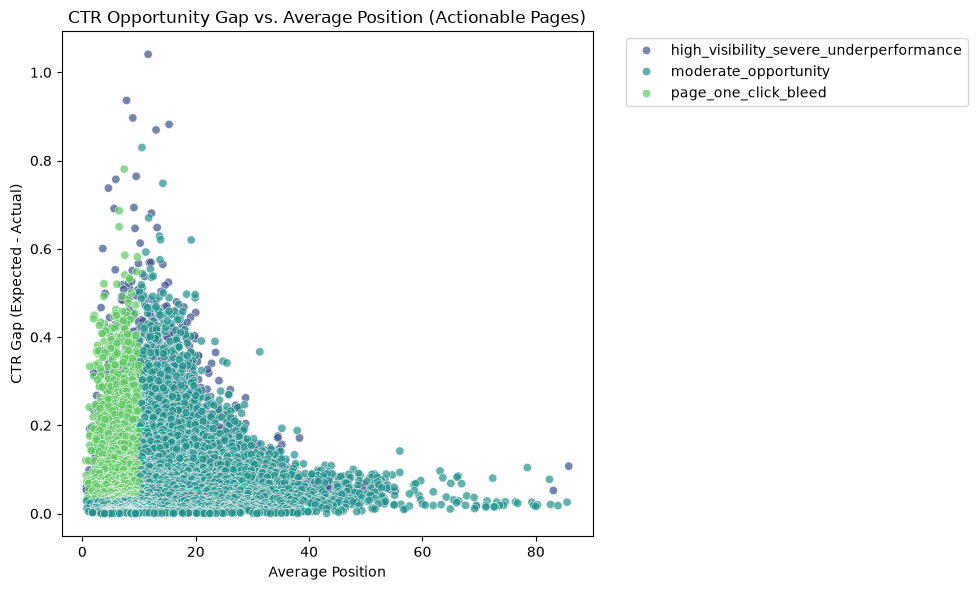

In [10]:
import os 
import matplotlib.pyplot as plt
import seaborn as sns

# Create directories
os.makedirs('../../outputs/charts', exist_ok=True)

# Export the CSV queue
csv_path = "../../outputs/ml_action_playbook_queue.csv"
df_playbook.to_csv(csv_path, index=False)
print(f"Ranked queue successfully exported to: {csv_path}")

# Export a figure to paper
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_playbook[df_playbook['ml_action_score'] > 0],
    x='avg_position',
    y='ctr_opportunity_gap',
    hue='playbook_reason',
    alpha=0.7,
    palette='viridis'
)

plt.title('CTR Opportunity Gap vs. Average Position (Actionable Pages)')
plt.xlabel('Average Position')
plt.ylabel('CTR Gap (Expected - Actual)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

chart_path = '../../outputs/charts/ctr_opportunity_landscape.png'
plt.savefig(chart_path)
print(f"Playbook visualization successfully exported to: {chart_path}")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [/] Every section above is filled — markdown thinking AND the code that backs it
- [/] The notebook runs top to bottom with no errors (Runtime → Run all)
- [/] No client names, URLs, or private queries anywhere
- [/] My claims use careful words: observed, measured, directional, decision-support
- [/] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.